# Tutorial 3. Use SEDR to do batch integration.

Here we use 3 sections from DLPFC data to show the ability of SEDR to integrate batches for the same tissue with the same techniques. 

In [1]:
import os
import torch
import numpy as np
import pandas as pd
import scanpy as sc

import matplotlib.pyplot as plt
import seaborn as sns

import warnings
warnings.filterwarnings('ignore')

from pathlib import Path
from tqdm import tqdm

In [2]:
import SEDR

os.environ['R_HOME'] = '/root/miniconda3/envs/njy1/lib/R'

In [3]:
SEDR.fix_seed(42)

In [4]:
data_root = Path('../../../Data/Mouse_Embryo/')

proj_list = [
    'E9.5_E1S1', 'E10.5_E2S1', 'E11.5_E1S1'
]

In [5]:
for proj_name in tqdm(proj_list):
    adata_tmp = sc.read_h5ad(os.path.join(data_root, proj_name + '.MOSTA.h5ad'))
    adata_tmp.var_names_make_unique()

    adata_tmp.obs['batch_name'] = proj_name
    graph_dict_tmp = SEDR.graph_construction(adata_tmp, 12)
    
    ##### Load layer_guess label, if have
    # df_label = pd.read_csv(data_root / proj_name / 'manual_annotations.txt', sep='\t', header=None, index_col=0)
    # df_label.columns = ['layer_guess']
    # adata_tmp.obs['layer_guess'] = df_label['layer_guess']
    
    if proj_name == proj_list[0]:
        adata = adata_tmp
        graph_dict = graph_dict_tmp
        name = proj_name
        adata.obs['proj_name'] = proj_name
    else:
        var_names = adata.var_names.intersection(adata_tmp.var_names)
        adata = adata[:, var_names]
        adata_tmp = adata_tmp[:, var_names]
        adata_tmp.obs['proj_name'] = proj_name
    
        adata = adata.concatenate(adata_tmp)
        graph_dict = SEDR.combine_graph_dict(graph_dict, graph_dict_tmp)
        name = name + '_' + proj_name

100%|██████████| 3/3 [01:23<00:00, 27.76s/it]


In [6]:
graph_dict

{'adj_norm': tensor(indices=tensor([[    0,     0,     0,  ..., 44530, 44530, 44530],
                        [    0,     1,     2,  ..., 44528, 44529, 44530]]),
        values=tensor([0.0769, 0.0769, 0.0769,  ..., 0.0769, 0.0769, 0.0769]),
        size=(44531, 44531), nnz=586741, layout=torch.sparse_coo),
 'adj_label': tensor(indices=tensor([[    0,     0,     0,  ..., 44530, 44530, 44530],
                        [    0,     1,     2,  ..., 44528, 44529, 44530]]),
        values=tensor([1., 1., 1.,  ..., 1., 1., 1.]),
        size=(44531, 44531), nnz=586741, dtype=torch.float64,
        layout=torch.sparse_coo),
 'norm_value': 0.5005852034866699}

In [7]:
adj_norm = graph_dict['adj_norm'].coalesce()

indices = adj_norm.indices()
values = adj_norm.values()

# 打印前5条边及其权重
for i in range(20):
    print(f"edge {i}: {indices[0, i].item()} -> {indices[1, i].item()}, weight = {values[i].item():.4f}")

edge 0: 0 -> 0, weight = 0.0769
edge 1: 0 -> 1, weight = 0.0769
edge 2: 0 -> 2, weight = 0.0769
edge 3: 0 -> 26, weight = 0.0769
edge 4: 0 -> 27, weight = 0.0741
edge 5: 0 -> 28, weight = 0.0769
edge 6: 0 -> 29, weight = 0.0741
edge 7: 0 -> 30, weight = 0.0716
edge 8: 0 -> 64, weight = 0.0693
edge 9: 0 -> 65, weight = 0.0716
edge 10: 0 -> 66, weight = 0.0716
edge 11: 0 -> 67, weight = 0.0693
edge 12: 0 -> 68, weight = 0.0693
edge 13: 1 -> 0, weight = 0.0769
edge 14: 1 -> 1, weight = 0.0769
edge 15: 1 -> 2, weight = 0.0769
edge 16: 1 -> 3, weight = 0.0769
edge 17: 1 -> 27, weight = 0.0741
edge 18: 1 -> 28, weight = 0.0769
edge 19: 1 -> 29, weight = 0.0741


## Preprocessing

In [8]:
adata.layers['count'] = adata.X.toarray()
sc.pp.filter_genes(adata, min_cells=50)
sc.pp.filter_genes(adata, min_counts=10)
sc.pp.normalize_total(adata, target_sum=1e6)
sc.pp.highly_variable_genes(adata, flavor="seurat_v3", layer='count', n_top_genes=2000)
adata = adata[:, adata.var['highly_variable'] == True]
sc.pp.scale(adata)

from sklearn.decomposition import PCA  # sklearn PCA is used because PCA in scanpy is not stable. 
adata_X = PCA(n_components=200, random_state=42).fit_transform(adata.X)
adata.obsm['X_pca'] = adata_X

In [9]:
# adata.write_h5ad("adata_E9.5E1S1-E10.5E2S1-E11.5E1S1.h5ad")

## Training SEDR

In [10]:
sedr_net = SEDR.Sedr(adata.obsm['X_pca'], graph_dict, mode='clustering', device='cuda:0')
using_dec = False
if using_dec:
    sedr_net.train_with_dec()
else:
    sedr_net.train_without_dec()
sedr_feat, _, _, _ = sedr_net.process()
adata.obsm['SEDR'] = sedr_feat

100%|██████████| 200/200 [00:59<00:00,  3.39it/s]


## use harmony to calculate revised PCs

In [11]:
import harmonypy as hm

meta_data = adata.obs[['batch_name']]

data_mat = adata.obsm['SEDR']
vars_use = ['batch_name']
ho = hm.run_harmony(data_mat, meta_data, vars_use)

res = pd.DataFrame(ho.Z_corr).T
res_df = pd.DataFrame(data=res.values, columns=['X{}'.format(i+1) for i in range(res.shape[1])], index=adata.obs.index)
adata.obsm[f'SEDR.Harmony'] = res_df.to_numpy()

2025-12-03 15:53:34,375 - harmonypy - INFO - Computing initial centroids with sklearn.KMeans...


2025-12-03 15:53:39,609 - harmonypy - INFO - sklearn.KMeans initialization complete.
2025-12-03 15:53:39,874 - harmonypy - INFO - Iteration 1 of 10
2025-12-03 15:53:52,955 - harmonypy - INFO - Iteration 2 of 10
2025-12-03 15:54:05,913 - harmonypy - INFO - Iteration 3 of 10
2025-12-03 15:54:18,978 - harmonypy - INFO - Iteration 4 of 10
2025-12-03 15:54:31,988 - harmonypy - INFO - Iteration 5 of 10
2025-12-03 15:54:44,338 - harmonypy - INFO - Iteration 6 of 10
2025-12-03 15:54:57,151 - harmonypy - INFO - Iteration 7 of 10
2025-12-03 15:55:10,202 - harmonypy - INFO - Converged after 7 iterations


In [12]:
SEDR.mclust_R(adata, use_rep='SEDR.Harmony', key_added='mclust', n_clusters=20)

R[write to console]:                    __           __ 
   ____ ___  _____/ /_  _______/ /_
  / __ `__ \/ ___/ / / / / ___/ __/
 / / / / / / /__/ / /_/ (__  ) /_  
/_/ /_/ /_/\___/_/\__,_/____/\__/   version 6.1.1
Type 'citation("mclust")' for citing this R package in publications.



fitting ...
  |======================================================================| 100%


AnnData object with n_obs × n_vars = 44531 × 2000
    obs: 'n_genes_by_counts', 'log1p_n_genes_by_counts', 'total_counts', 'log1p_total_counts', 'annotation', 'Regulon - 2310011J03Rik', 'Regulon - 5730507C01Rik', 'Regulon - Alx1', 'Regulon - Alx3', 'Regulon - Alx4', 'Regulon - Ar', 'Regulon - Arid3a', 'Regulon - Arid3c', 'Regulon - Arnt2', 'Regulon - Arx', 'Regulon - Ascl1', 'Regulon - Atf1', 'Regulon - Atf4', 'Regulon - Atf5', 'Regulon - Atf6', 'Regulon - Atf7', 'Regulon - Bach1', 'Regulon - Bach2', 'Regulon - Barhl1', 'Regulon - Barx1', 'Regulon - Batf', 'Regulon - Bcl11a', 'Regulon - Bcl3', 'Regulon - Bcl6', 'Regulon - Bcl6b', 'Regulon - Bclaf1', 'Regulon - Bdp1', 'Regulon - Bhlha15', 'Regulon - Bhlhe22', 'Regulon - Bhlhe23', 'Regulon - Bhlhe41', 'Regulon - Bmyc', 'Regulon - Boll', 'Regulon - Bptf', 'Regulon - Brca1', 'Regulon - Brf1', 'Regulon - Brf2', 'Regulon - Bsx', 'Regulon - Cdx1', 'Regulon - Cdx2', 'Regulon - Cebpa', 'Regulon - Cebpz', 'Regulon - Chd1', 'Regulon - Clock', 'Re

In [ ]:
# adata = sc.read_h5ad('adata_SEDR_MOE.h5ad')

In [6]:
from sklearn.metrics import adjusted_rand_score as ari_score
from sklearn.metrics import normalized_mutual_info_score as nmi_score
from sklearn.metrics import adjusted_mutual_info_score as ami_score
from sklearn.metrics import homogeneity_score as hom_score
from sklearn.metrics import completeness_score as com_score

In [7]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
ARI = ari_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total ARI:{ARI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    ARI = ari_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} ARI:{ARI}")

total ARI:0.22670154914723548
E9.5_E1S1 ARI:0.2354802286160472
E10.5_E2S1 ARI:0.25569727177170554
E11.5_E1S1 ARI:0.2867870830396212


In [8]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
NMI = nmi_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{NMI}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    NMI = nmi_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} NMI:{NMI}")

total NMI:0.49250621348703677
E9.5_E1S1 NMI:0.49012107361992324
E10.5_E2S1 NMI:0.5408163180644363
E11.5_E1S1 NMI:0.5592389893760443


In [9]:
sub_adata = adata[~pd.isnull(adata.obs['annotation'])]
HOM = hom_score(sub_adata.obs['annotation'], sub_adata.obs['mclust'])
print(f"total NMI:{HOM}")
for name in proj_list:
    sub_adata_tmp = sub_adata[sub_adata.obs['batch_name'] == name]
    HOM = hom_score(sub_adata_tmp.obs['annotation'], sub_adata_tmp.obs['mclust'])
    print(f"{name} HOM:{HOM}")

total NMI:0.4867379899307956
E9.5_E1S1 HOM:0.5456425556400932
E10.5_E2S1 HOM:0.5501321319595995
E11.5_E1S1 HOM:0.5758867359779742


In [18]:
import scib

sc.pp.neighbors(adata, use_rep="SEDR")
scib.me.graph_connectivity(adata, label_key="annotation")

/root/miniconda3/envs/njy1/lib/python3.9/site-packages/numba/np/ufunc/parallel.py:371: NumbaWarning: The TBB threading layer requires TBB version 2021 update 6 or later i.e., TBB_INTERFACE_VERSION >= 12060. Found TBB_INTERFACE_VERSION = 12050. The TBB threading layer is disabled.
  warnings.warn(problem)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future version. Use pd.Series(obj).value_counts() instead.
  tab = pd.value_counts(labels)
/root/miniconda3/envs/njy1/lib/python3.9/site-packages/scib/metrics/graph_connectivity.py:56: FutureWarning: pandas.value_counts is deprecated and will be removed in a future v

0.8495634628727622

In [19]:
scib.me.silhouette_batch(adata, batch_key="batch_name", label_key="annotation", embed="SEDR")

mean silhouette per group:                       silhouette_score
group                                 
Blood vessel                  0.670912
Brain                         0.816427
Branchial arch                0.441006
Cavity                        0.822188
Connective tissue             0.659899
Dermomyotome                  0.788086
Dorsal root ganglion          0.778557
Head mesenchyme               0.592215
Heart                         0.860485
Jaw and tooth                 0.609306
Liver                         0.627629
Lung primordium               0.546100
Mesenchyme                    0.792995
Notochord                     0.441631
Sclerotome                    0.663357
Spinal cord                   0.771881
Urogenital ridge              0.782396


0.6861805958394614

1.2054659023242997
1.1840470099159024


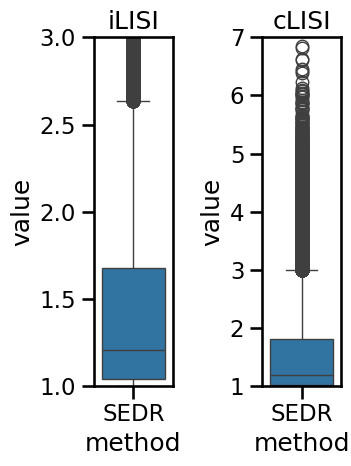

In [20]:
import seaborn as sns
import harmonypy as hm
import matplotlib.pyplot as plt

iLISI = hm.compute_lisi(adata.obsm['SEDR.Harmony'], adata.obs[['batch_name']], label_colnames=['batch_name'])[:, 0]
cLISI = hm.compute_lisi(adata.obsm['SEDR.Harmony'], adata.obs[['annotation']], label_colnames=['annotation'])[:, 0]

df_iLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': iLISI,
    'type': ['ILISI'] * len(iLISI)
})

df_cLISI = pd.DataFrame({
    'method': 'SEDR',
    'value': cLISI,
    'type': ['CLISI'] * len(cLISI)
})

fig, axes = plt.subplots(1, 2, figsize=(4, 5))
sns.boxplot(data=df_iLISI, x='method', y='value', ax=axes[0])
sns.boxplot(data=df_cLISI, x='method', y='value', ax=axes[1])
axes[0].set_ylim(1, 3)
axes[1].set_ylim(1, 7)
axes[0].set_title('iLISI')
axes[1].set_title('cLISI')

plt.tight_layout()
print(np.median(iLISI))
print(np.median(cLISI))

## Visualizing

### UMAP

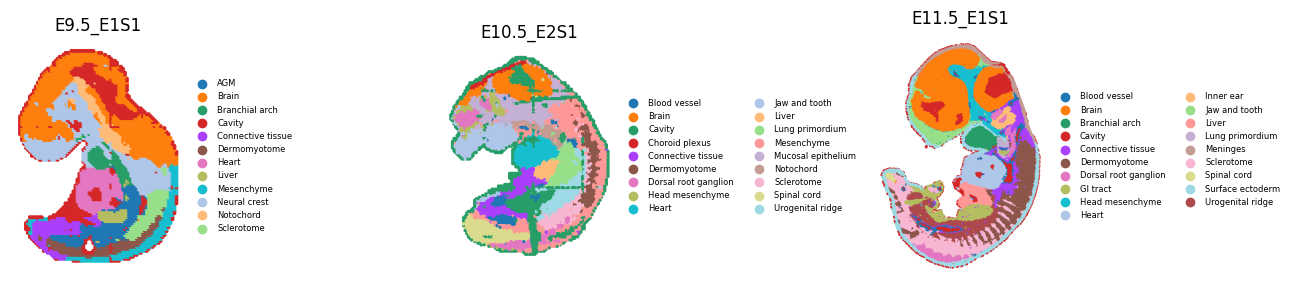

In [15]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['annotation'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

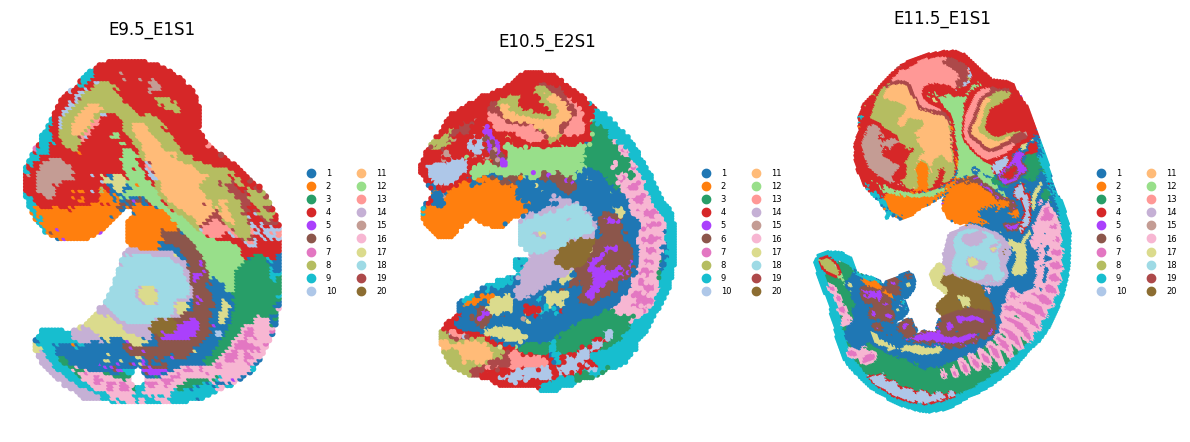

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(15, 10))
k = 1
spot_size = 2
for slice_id, slice_name in enumerate(proj_list):
    adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
    ax = plt.subplot(2, 4, k)
    # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
    sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
                  legend_loc='right margin', legend_fontsize=6, show=False, ax=ax, frameon=False,
                  spot_size=spot_size)
    plt.title(f'{slice_name}')
    k += 1
plt.tight_layout()

In [21]:
# for slice_id, slice_name in enumerate(proj_list):
#     adata_tmp = adata[adata.obs['batch_name'] == proj_list[slice_id]]
#     # sc.pl.embedding(adata_tmp, basis='spatial', color='annotation', s=45, ax=ax, show=False, legend_loc=False)
#     sc.pl.spatial(adata_tmp, img_key=None, color=['mclust'], title=[''],
#                   legend_loc=None, legend_fontsize=6, show=False, frameon=False,
#                   spot_size=spot_size)
#     #plt.title(f'{slice_name}')
#     plt.savefig(f'SEDR_{slice_name}.png', bbox_inches='tight', dpi=300)
# plt.tight_layout()

In [18]:
#adata.write("adata_SEDR_MOE.h5ad")